# TP — Algorithmes de Clustering

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.cluster import KMeans, DBSCAN, MeanShift, estimate_bandwidth, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score, adjusted_rand_score

RANDOM_STATE = 101
np.random.seed(RANDOM_STATE)


## Outils (fonctions)

In [3]:
def _safe_silhouette(X, labels):
    # silhouette is undefined if 1 cluster, or all noise
    unique = set(labels)
    if len(unique) <= 1:
        return np.nan
    if unique == {-1}:
        return np.nan
    # if noise exists, silhouette can still be computed; keep it.
    try:
        return silhouette_score(X, labels)
    except Exception:
        return np.nan

def cluster_all(X, y_true=None, n_clusters=None, dbscan_eps=0.5, dbscan_min_samples=5, ms_bandwidth=None):
    Xs = StandardScaler().fit_transform(X)

    models = {}

    if n_clusters is not None:
        models["KMeans"] = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init="auto")
        models["CAH"] = AgglomerativeClustering(n_clusters=n_clusters)
        models["GMM"] = GaussianMixture(n_components=n_clusters, random_state=RANDOM_STATE)

    models["DBSCAN"] = DBSCAN(eps=dbscan_eps, min_samples=dbscan_min_samples)

    if ms_bandwidth is None:
        # heuristic bandwidth; quantile controls smoothness
        ms_bandwidth = estimate_bandwidth(Xs, quantile=0.2, n_samples=min(500, len(Xs)))
        if ms_bandwidth <= 1e-9:
            ms_bandwidth = 0.5
    models["MeanShift"] = MeanShift(bandwidth=ms_bandwidth, bin_seeding=True)

    out = {}
    for name, model in models.items():
        if name == "GMM":
            model.fit(Xs)
            labels = model.predict(Xs)
        else:
            labels = model.fit_predict(Xs)

        sil = _safe_silhouette(Xs, labels)
        ari = adjusted_rand_score(y_true, labels) if y_true is not None else np.nan
        out[name] = {"labels": labels, "silhouette": sil, "ari": ari, "n_clusters_found": len(set(labels)) - (1 if -1 in labels else 0)}
    return out, ms_bandwidth

def plot_clusters_2d(X, labels, title=""):
    plt.figure(figsize=(5, 4))
    plt.scatter(X[:, 0], X[:, 1], c=labels, s=12)
    plt.title(title)
    plt.tight_layout()
    plt.show()


## Partie II — Données synthétiques (Blobs)

### Question 2.1 — Génération des données

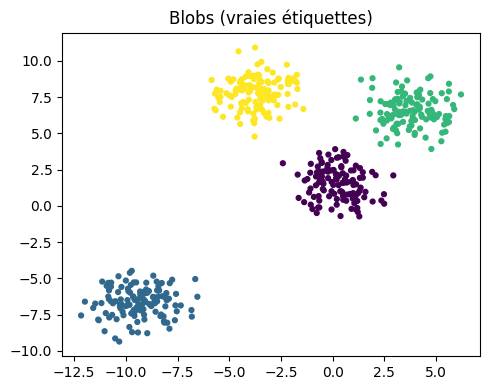

In [4]:
nbr_clusters = 4
std_clusters = 1

X_blobs, y_blobs, centers = make_blobs(
    n_samples=500, n_features=2, centers=nbr_clusters,
    cluster_std=std_clusters, random_state=RANDOM_STATE,
    return_centers=True
)

plt.figure(figsize=(5,4))
plt.scatter(X_blobs[:,0], X_blobs[:,1], c=y_blobs, s=12)
plt.title("Blobs (vraies étiquettes)")
plt.tight_layout()
plt.show()


### Question 2.2 — Application des algorithmes (visualisation)

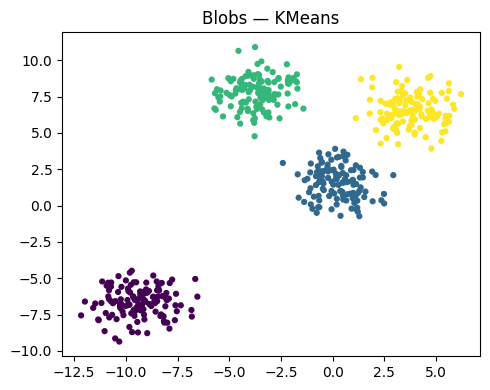

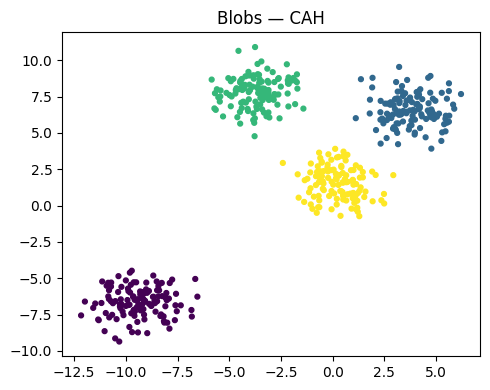

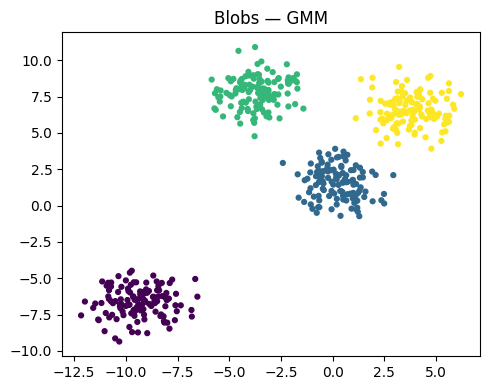

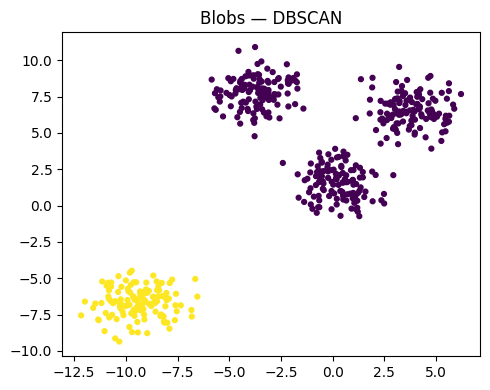

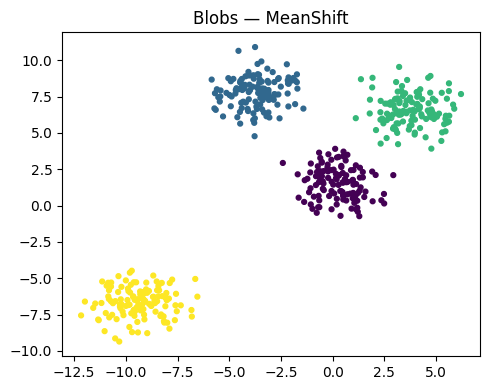

In [5]:
res_blobs, bw_blobs = cluster_all(
    X_blobs, y_true=y_blobs, n_clusters=nbr_clusters,
    dbscan_eps=0.6, dbscan_min_samples=5
)

for algo, info in res_blobs.items():
    plot_clusters_2d(X_blobs, info["labels"], f"Blobs — {algo}")


### Question 2.3 — Nombre de clusters + Silhouette + ARI

In [6]:
import pandas as pd

rows = []
for algo, info in res_blobs.items():
    rows.append({
        "algo": algo,
        "clusters_detectes": info["n_clusters_found"],
        "silhouette": info["silhouette"],
        "ARI": info["ari"],
    })

df_blobs = pd.DataFrame(rows).sort_values("algo")
df_blobs


,algo,clusters_detectes,silhouette,ARI
1,CAH,4,0.742764,1.000000
3,DBSCAN,2,0.698062,0.331995
2,GMM,4,0.742764,1.000000
0,KMeans,4,0.742764,1.000000
4,MeanShift,4,0.742764,1.000000


### Question 2.4 — Meilleur algorithme (selon métriques)

In [ ]:
# On prend comme critère principal l'ARI (si y_true dispo), sinon silhouette
df_blobs_sorted = df_blobs.sort_values(["ARI", "silhouette"], ascending=False)
df_blobs_sorted


## Partie III — Segmentation d'image simple (niveaux de gris)

### Question 3.1 — Création de l'image + data

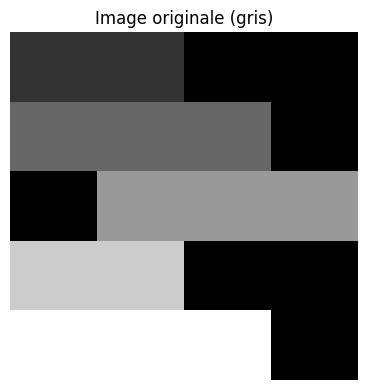

In [7]:
image = np.zeros((100, 100))
image[0:20, 0:50] = 50
image[20:40, 0:75] = 100
image[40:60, 25:100] = 150
image[60:80, 0:50] = 200
image[80:100, 0:75] = 250

data_gray = image.reshape(-1, 1)

plt.figure(figsize=(4,4))
plt.imshow(image, cmap="gray")
plt.title("Image originale (gris)")
plt.axis("off")
plt.tight_layout()
plt.show()


### Question 3.2 — Application des algorithmes (K=5 pour KMeans/CAH/GMM)

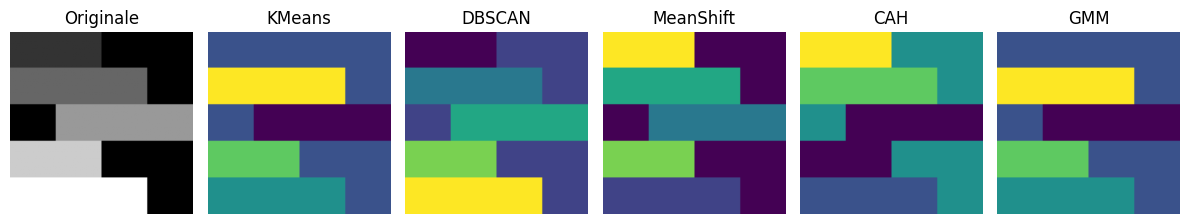

,algo,clusters_detectes,silhouette
1,CAH,5,0.879952
3,DBSCAN,6,1.000000
2,GMM,5,0.883307
0,KMeans,5,0.883307
4,MeanShift,6,1.000000


In [8]:
def segment_gray(data_1d, shape, n_clusters=5, dbscan_eps=0.35, ms_bandwidth=None):
    # data_1d: (N,1)
    X = data_1d.astype(float)
    res, bw = cluster_all(X, y_true=None, n_clusters=n_clusters, dbscan_eps=dbscan_eps, ms_bandwidth=ms_bandwidth)
    segs = {}
    for algo, info in res.items():
        segs[algo] = info["labels"].reshape(shape)
    return segs, bw, res

segs_gray, bw_gray, res_gray = segment_gray(data_gray, image.shape, n_clusters=5, dbscan_eps=0.35)

plt.figure(figsize=(12, 4))
plt.subplot(1, 6, 1)
plt.imshow(image, cmap="gray")
plt.title("Originale")
plt.axis("off")

for i, algo in enumerate(["KMeans", "DBSCAN", "MeanShift", "CAH", "GMM"], start=2):
    plt.subplot(1, 6, i)
    plt.imshow(segs_gray[algo])
    plt.title(algo)
    plt.axis("off")

plt.tight_layout()
plt.show()

pd.DataFrame([{
    "algo": a,
    "clusters_detectes": info["n_clusters_found"],
    "silhouette": info["silhouette"],
} for a, info in res_gray.items()]).sort_values("algo")


### Question 3.3 — Effet de eps (DBSCAN)

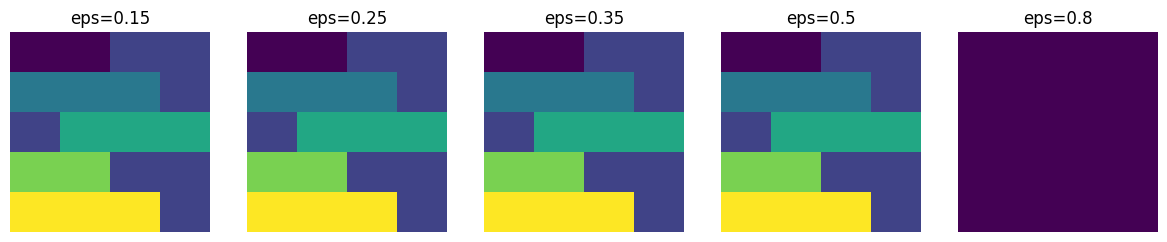

In [9]:
eps_values = [0.15, 0.25, 0.35, 0.5, 0.8]

plt.figure(figsize=(12, 2.4))
for i, eps in enumerate(eps_values, start=1):
    segs, _, _ = segment_gray(data_gray, image.shape, n_clusters=5, dbscan_eps=eps, ms_bandwidth=bw_gray)
    plt.subplot(1, len(eps_values), i)
    plt.imshow(segs["DBSCAN"])
    plt.title(f"eps={eps}")
    plt.axis("off")
plt.tight_layout()
plt.show()


## Partie IV — Formes complexes (Moons & Circles)

### Question 4.1 — Moons (visualisation + clustering)

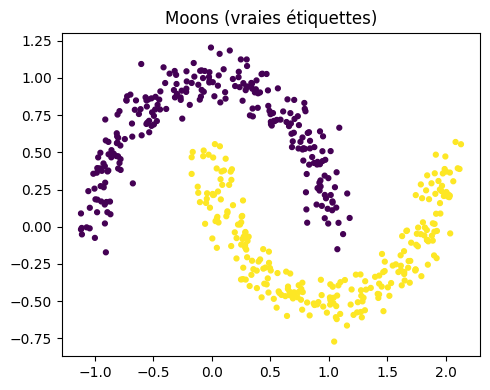

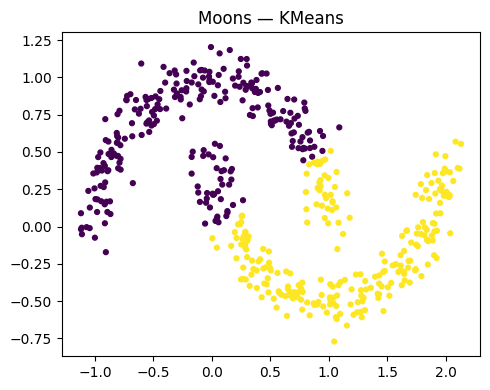

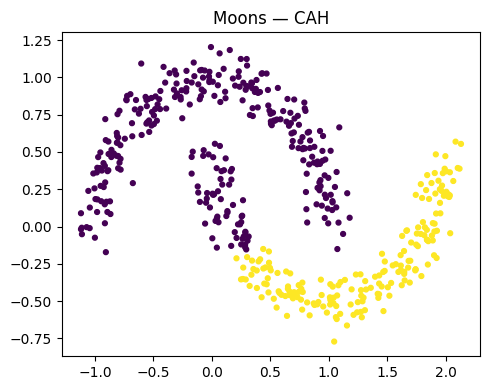

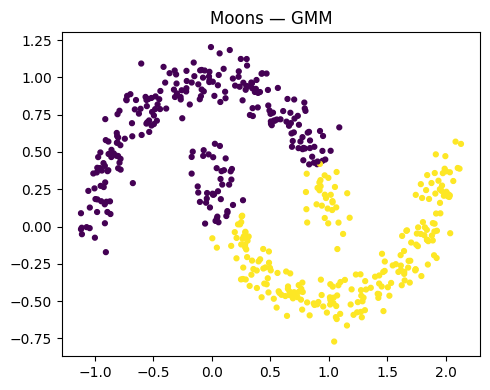

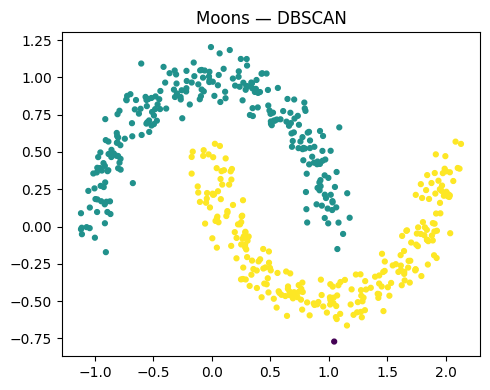

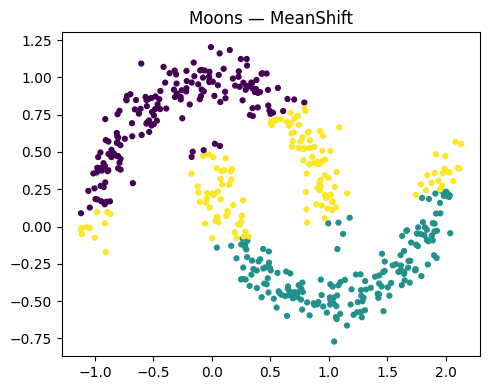

,algo,clusters_detectes,silhouette,ARI
3,DBSCAN,2,0.163322,0.996008
1,CAH,2,0.454727,0.570727
2,GMM,2,0.492504,0.505956
0,KMeans,2,0.491356,0.466788
4,MeanShift,3,0.358715,0.435825


In [10]:
X_moons, y_moons = make_moons(n_samples=500, noise=0.09, random_state=0)

res_moons, bw_moons = cluster_all(
    X_moons, y_true=y_moons, n_clusters=2,
    dbscan_eps=0.25, dbscan_min_samples=5
)

plt.figure(figsize=(5,4))
plt.scatter(X_moons[:,0], X_moons[:,1], c=y_moons, s=12)
plt.title("Moons (vraies étiquettes)")
plt.tight_layout()
plt.show()

for algo, info in res_moons.items():
    plot_clusters_2d(X_moons, info["labels"], f"Moons — {algo}")

import pandas as pd
pd.DataFrame([{
    "algo": a,
    "clusters_detectes": info["n_clusters_found"],
    "silhouette": info["silhouette"],
    "ARI": info["ari"]
} for a, info in res_moons.items()]).sort_values(["ARI","silhouette"], ascending=False)


### Question 4.2 — Circles (visualisation + clustering)

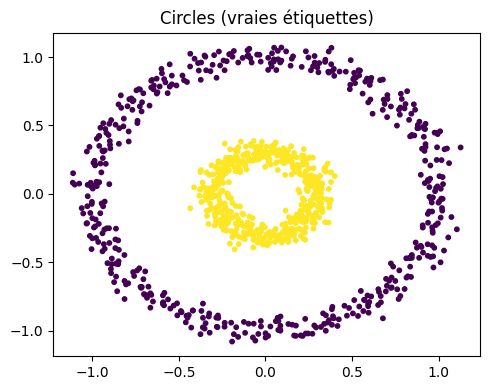

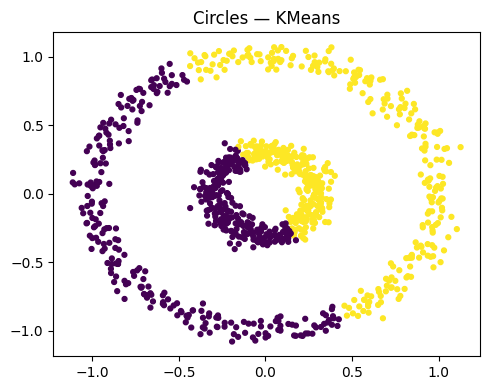

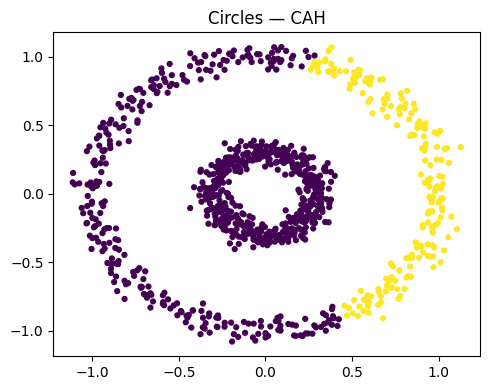

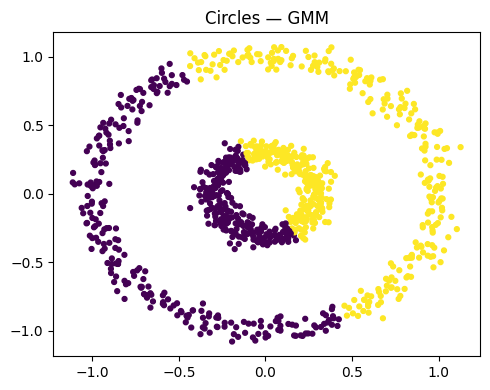

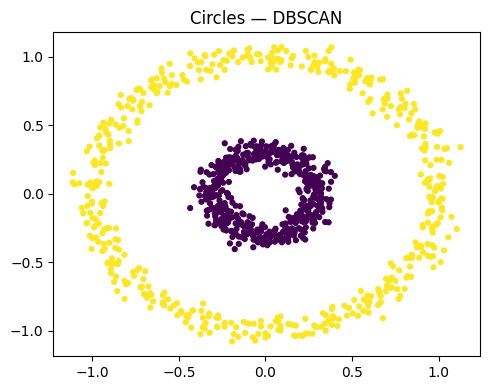

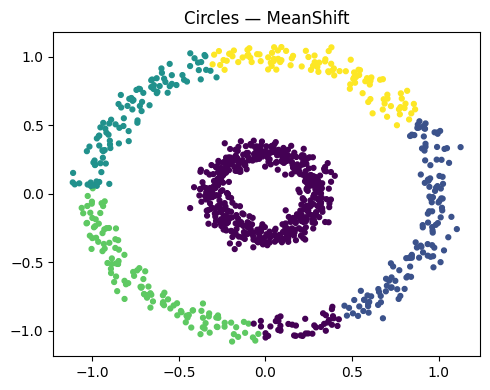

,algo,clusters_detectes,silhouette,ARI
3,DBSCAN,2,0.207752,1.000000
4,MeanShift,5,0.422065,0.522885
1,CAH,2,0.351853,0.148465
2,GMM,2,0.293862,-0.000677
0,KMeans,2,0.293817,-0.000858


In [11]:
X_circles, y_circles = make_circles(n_samples=1000, factor=0.3, noise=0.05, random_state=0)

res_circles, bw_circles = cluster_all(
    X_circles, y_true=y_circles, n_clusters=2,
    dbscan_eps=0.2, dbscan_min_samples=5
)

plt.figure(figsize=(5,4))
plt.scatter(X_circles[:,0], X_circles[:,1], c=y_circles, s=10)
plt.title("Circles (vraies étiquettes)")
plt.tight_layout()
plt.show()

for algo, info in res_circles.items():
    plot_clusters_2d(X_circles, info["labels"], f"Circles — {algo}")

pd.DataFrame([{
    "algo": a,
    "clusters_detectes": info["n_clusters_found"],
    "silhouette": info["silhouette"],
    "ARI": info["ari"]
} for a, info in res_circles.items()]).sort_values(["ARI","silhouette"], ascending=False)


### Question 4.3 — Algorithmes qui échouent (Moons/Circles)

In [12]:
def best_by_ari(df):
    return df.sort_values("ARI", ascending=False).head(1)

df_moons = pd.DataFrame([{"algo": a, "ARI": i["ari"], "silhouette": i["silhouette"], "clusters": i["n_clusters_found"]} for a,i in res_moons.items()])
df_circles = pd.DataFrame([{"algo": a, "ARI": i["ari"], "silhouette": i["silhouette"], "clusters": i["n_clusters_found"]} for a,i in res_circles.items()])

df_moons.sort_values("ARI", ascending=False), df_circles.sort_values("ARI", ascending=False)


(        algo       ARI  silhouette  clusters
 3     DBSCAN  0.996008    0.163322         2
 1        CAH  0.570727    0.454727         2
 2        GMM  0.505956    0.492504         2
 0     KMeans  0.466788    0.491356         2
 4  MeanShift  0.435825    0.358715         3,
         algo       ARI  silhouette  clusters
 3     DBSCAN  1.000000    0.207752         2
 4  MeanShift  0.522885    0.422065         5
 1        CAH  0.148465    0.351853         2
 2        GMM -0.000677    0.293862         2
 0     KMeans -0.000858    0.293817         2)

## Partie V — Segmentation d'image couleur

### Question 5.1 — Chargement et préparation

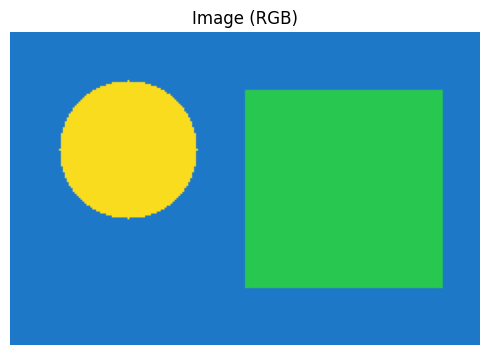

In [16]:
import os
import cv2 as cv

IMG_PATH = "/mnt/data/path.jpg"  # <- change si besoin

def load_or_make_image(path):
    if os.path.exists(path):
        img_bgr = cv.imread(path)
        img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
        return img_rgb
    # fallback: petite image synthétique
    h, w = 160, 240
    img = np.zeros((h, w, 3), dtype=np.uint8)
    img[:,:] = (30, 120, 200)
    cv.circle(img, (60, 60), 35, (250, 220, 30), -1)
    cv.rectangle(img, (120, 30), (220, 130), (40, 200, 80), -1)
    return img

img = load_or_make_image(IMG_PATH)
plt.figure(figsize=(5,4))
plt.imshow(img)
plt.title("Image (RGB)")
plt.axis("off")
plt.tight_layout()
plt.show()

data_rgb = img.reshape(-1, 3)


### Question 5.2 — Application des algorithmes

c:\Users\chikh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1365: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\chikh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1365: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


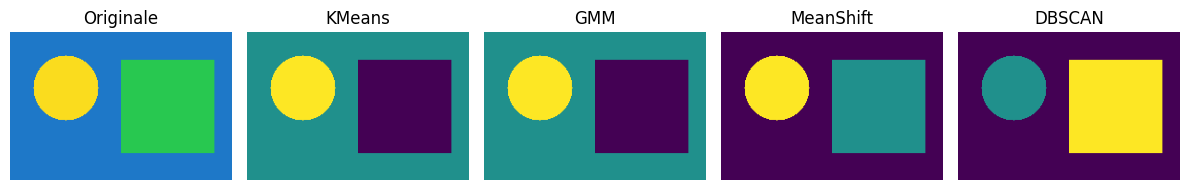

np.float64(0.33968085145371996)

In [17]:
def segment_color(img_rgb, k=6, dbscan_eps=0.25, dbscan_min_samples=20, ms_quantile=0.12, max_pixels=50000):
    h, w, _ = img_rgb.shape
    X = img_rgb.reshape(-1, 3).astype(float)

    # optional subsample for heavy algorithms (MeanShift/DBSCAN)
    idx = np.arange(len(X))
    if len(idx) > max_pixels:
        idx = np.random.choice(idx, size=max_pixels, replace=False)
    Xs = StandardScaler().fit_transform(X)

    # KMeans (fast)
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    km_labels = km.fit_predict(Xs)

    # GMM
    gmm = GaussianMixture(n_components=k, random_state=RANDOM_STATE)
    gmm.fit(Xs)
    gmm_labels = gmm.predict(Xs)

    # MeanShift
    bw = estimate_bandwidth(Xs[idx], quantile=ms_quantile, n_samples=min(5000, len(idx)))
    if bw <= 1e-9:
        bw = 0.6
    ms = MeanShift(bandwidth=bw, bin_seeding=True)
    ms_labels = ms.fit_predict(Xs)

    # DBSCAN (often slow / noisy in RGB)
    db = DBSCAN(eps=dbscan_eps, min_samples=dbscan_min_samples)
    db_labels = db.fit_predict(Xs)

    return {
        "KMeans": km_labels.reshape(h, w),
        "GMM": gmm_labels.reshape(h, w),
        "MeanShift": ms_labels.reshape(h, w),
        "DBSCAN": db_labels.reshape(h, w),
        "MeanShift_bandwidth": bw
    }

seg = segment_color(img, k=6, dbscan_eps=0.22, dbscan_min_samples=25, ms_quantile=0.12)

plt.figure(figsize=(12, 4))
plt.subplot(1, 5, 1)
plt.imshow(img)
plt.title("Originale")
plt.axis("off")

for i, algo in enumerate(["KMeans", "GMM", "MeanShift", "DBSCAN"], start=2):
    plt.subplot(1, 5, i)
    plt.imshow(seg[algo])
    plt.title(algo)
    plt.axis("off")

plt.tight_layout()
plt.show()

seg["MeanShift_bandwidth"]


### Question 5.3 — Effet du bandwidth (MeanShift)

c:\Users\chikh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1365: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\chikh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1365: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\chikh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1365: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\chikh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1365: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (6). Possibly du

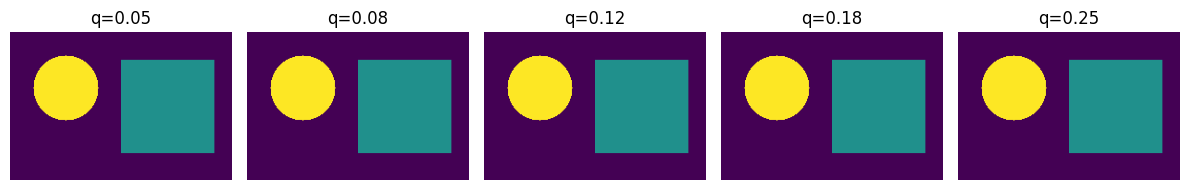

In [18]:
quantiles = [0.05, 0.08, 0.12, 0.18, 0.25]

plt.figure(figsize=(12, 2.4))
for i, q in enumerate(quantiles, start=1):
    segq = segment_color(img, k=6, dbscan_eps=0.22, dbscan_min_samples=25, ms_quantile=q)
    plt.subplot(1, len(quantiles), i)
    plt.imshow(segq["MeanShift"])
    plt.title(f"q={q}")
    plt.axis("off")
plt.tight_layout()
plt.show()
